Found 20947 images belonging to 10 classes.
Found 5232 images belonging to 10 classes.
Процес навчання нейронної мережі розпочато.
Epoch 1/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 82s 225ms/step - accuracy: 0.3586 - loss: 2.1139 - val_accuracy: 0.2515 - val_loss: 2.9123
Epoch 2/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 69s 211ms/step - accuracy: 0.5034 - loss: 1.4655 - val_accuracy: 0.4195 - val_loss: 1.6857
Epoch 3/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 65s 199ms/step - accuracy: 0.5678 - loss: 1.2731 - val_accuracy: 0.5004 - val_loss: 1.4312
Epoch 4/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 61s 185ms/step - accuracy: 0.6069 - loss: 1.1602 - val_accuracy: 0.4558 - val_loss: 1.8518
Epoch 5/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 67s 203ms/step - accuracy: 0.6468 - loss: 1.0628 - val_accuracy: 0.6252 - val_loss: 1.1043
Epoch 6/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 70s 213ms/step - accuracy: 0.6753 - loss: 0.9674 - val_accuracy: 0.6416 - val_loss: 1.0619
Epoch 7/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 80s 207ms/step - accuracy: 0.7036 - loss: 0

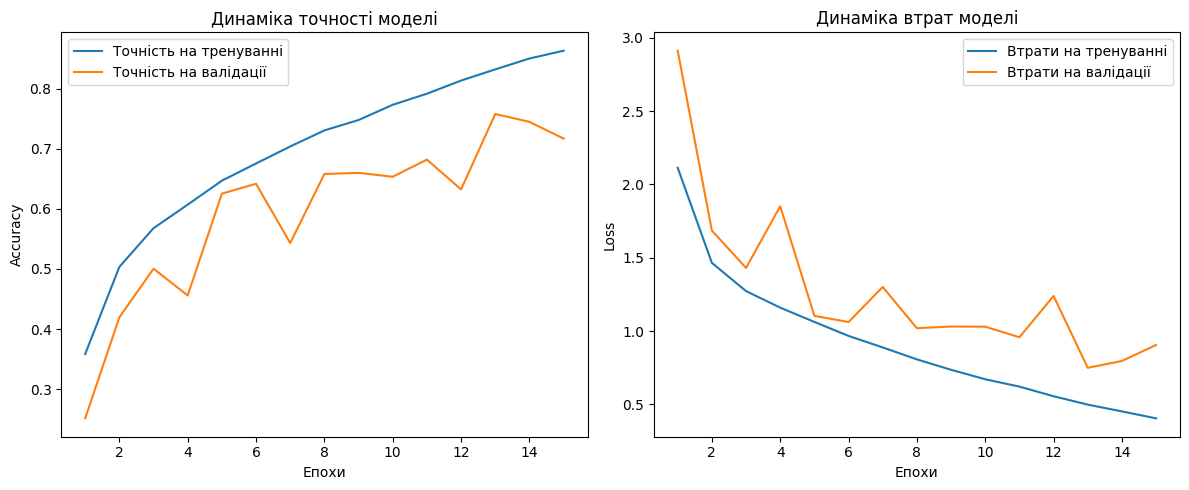

Аналіз ефективності моделі та розрахунок метрик.

Отримані значення статистичних метрик:
Accuracy (Загальна точність): 0.7167
Precision (Точність передбачення): 0.7514
Recall (Повнота охоплення): 0.6522
F-Score (Гармонійне середнє): 0.6704



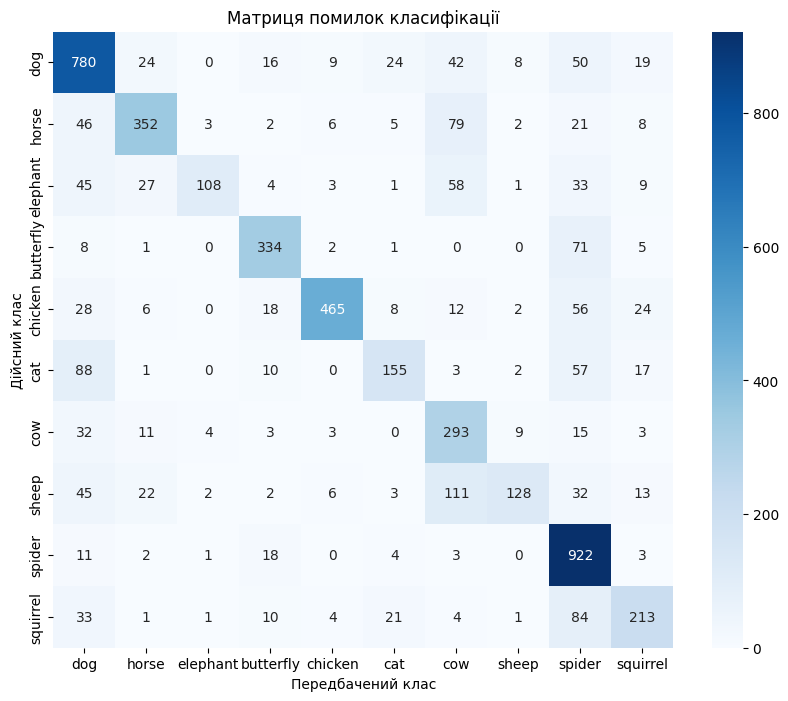

Результат розпізнавання для завантаженого зображення: dog


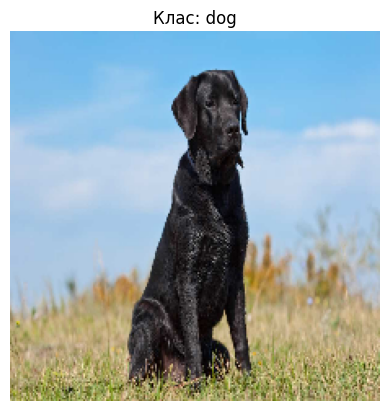

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

BASE_DIR = 'raw-img'
IMG_SIZE = (227, 227)
BATCH_SIZE = 64
EPOCHS = 15

labels_dict = {
    'cane': 'dog', 'cavallo': 'horse', 'elefante': 'elephant', 'farfalla': 'butterfly',
    'gallina': 'chicken', 'gatto': 'cat', 'mucca': 'cow', 'pecora': 'sheep',
    'scoiattolo': 'squirrel', 'ragno': 'spider'
}

train_datagen = ImageDataGenerator(rescale=1.0 / 255, validation_split=0.2, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1.0 / 255, validation_split=0.2)

train_gen = train_datagen.flow_from_directory(
    BASE_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    BASE_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False
)

def build_alexnet(num_classes=10):
    return Sequential([
        Input(shape=(227, 227, 3)),
        Conv2D(96, (11, 11), strides=4, activation='relu'),
        BatchNormalization(),
        MaxPooling2D(3, strides=2),
        Conv2D(256, (5, 5), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(3, strides=2),
        Conv2D(384, (3, 3), padding='same', activation='relu'),
        Conv2D(384, (3, 3), padding='same', activation='relu'),
        Conv2D(256, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(3, strides=2),
        Flatten(),
        Dense(4096, activation='relu'),
        Dropout(0.5),
        Dense(4096, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

model = build_alexnet()
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

print("Процес навчання нейронної мережі розпочато.")
history = model.fit(train_gen, epochs=EPOCHS, validation_data=val_gen, verbose=1)

print("Візуалізація результатів навчання.")
acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
loss, val_loss = history.history['loss'], history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Точність на тренуванні')
plt.plot(epochs_range, val_acc, label='Точність на валідації')
plt.title('Динаміка точності моделі')
plt.xlabel('Епохи')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Втрати на тренуванні')
plt.plot(epochs_range, val_loss, label='Втрати на валідації')
plt.title('Динаміка втрат моделі')
plt.xlabel('Епохи')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

print("Аналіз ефективності моделі та розрахунок метрик.")
predictions = model.predict(val_gen, verbose=0)
y_pred = np.argmax(predictions, axis=1)
y_true = val_gen.classes

print("\nОтримані значення статистичних метрик:")
print(f"Accuracy (Загальна точність): {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision (Точність передбачення): {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"Recall (Повнота охоплення): {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"F-Score (Гармонійне середнє): {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}\n")

target_names = [labels_dict.get(c, c) for c in list(val_gen.class_indices.keys())]
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Матриця помилок класифікації')
plt.ylabel('Дійсний клас')
plt.xlabel('Передбачений клас')
plt.show()

def predict_external(img_path):
    if not os.path.exists(img_path):
        print(f"Помилка: Файл {img_path} не знайдено.")
        return

    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    res = model.predict(img_array, verbose=0)
    idx = np.argmax(res)

    inv_map = {v: k for k, v in train_gen.class_indices.items()}
    class_res = labels_dict.get(inv_map[idx], inv_map[idx])

    print(f"Результат розпізнавання для завантаженого зображення: {class_res}")
    plt.imshow(img)
    plt.title(f"Клас: {class_res}")
    plt.axis('off')
    plt.show()

predict_external('labrador.jpg')

Процес навчання оптимізованої моделі розпочато.
Epoch 1/5
328/328 ━━━━━━━━━━━━━━━━━━━━ 69s 190ms/step - accuracy: 0.3497 - loss: 2.0047 - val_accuracy: 0.2750 - val_loss: 2.7118
Epoch 2/5
328/328 ━━━━━━━━━━━━━━━━━━━━ 65s 198ms/step - accuracy: 0.4807 - loss: 1.5141 - val_accuracy: 0.5187 - val_loss: 1.4017
Epoch 3/5
328/328 ━━━━━━━━━━━━━━━━━━━━ 60s 183ms/step - accuracy: 0.5400 - loss: 1.3435 - val_accuracy: 0.5434 - val_loss: 1.4173
Epoch 4/5
328/328 ━━━━━━━━━━━━━━━━━━━━ 60s 184ms/step - accuracy: 0.5895 - loss: 1.2120 - val_accuracy: 0.5396 - val_loss: 1.3428
Epoch 5/5
328/328 ━━━━━━━━━━━━━━━━━━━━ 62s 188ms/step - accuracy: 0.6227 - loss: 1.1104 - val_accuracy: 0.5747 - val_loss: 1.3465

 ПОРІВНЯЛЬНИЙ АНАЛІЗ ОБЧИСЛЮВАЛЬНОЇ СКЛАДНОСТІ
Критерій                  | Оригінал     | Оптимізована
-------------------------------------------------------
Кількість параметрів      |   58,324,746 |    2,980,042
Об’єм пам’яті (MB)        |       222.49 |        11.37
Швидкість обробки (сек)   |   

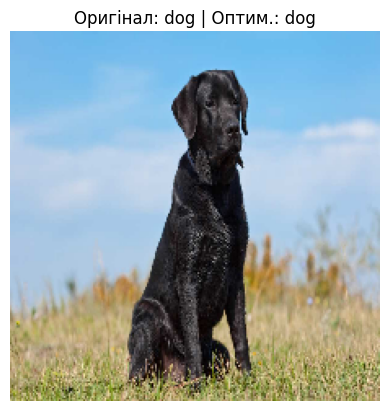

In [6]:
import time
import psutil
from tensorflow.keras.layers import GlobalAveragePooling2D

def build_optimized_alexnet(num_classes=10):
    model = Sequential([
        Input(shape=(227, 227, 3)),
        Conv2D(48, (11, 11), strides=4, activation='relu'),
        BatchNormalization(),
        MaxPooling2D(3, strides=2),

        Conv2D(128, (5, 5), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(3, strides=2),

        Conv2D(192, (3, 3), padding='same', activation='relu'),
        Conv2D(128, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(3, strides=2),

        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

opt_model = build_optimized_alexnet()
opt_model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

print("Процес навчання оптимізованої моделі розпочато.")
start_train = time.time()
opt_history = opt_model.fit(train_gen, epochs=5, validation_data=val_gen, verbose=1)
train_time_opt = time.time() - start_train

orig_params = model.count_params()
opt_params = opt_model.count_params()

orig_mem = (orig_params * 4) / (1024**2)
opt_mem = (opt_params * 4) / (1024**2)

sample_batch = np.random.rand(1, 227, 227, 3)

t1 = time.time()
for _ in range(50): model.predict(sample_batch, verbose=0)
inference_orig = (time.time() - t1) / 50

t2 = time.time()
for _ in range(50): opt_model.predict(sample_batch, verbose=0)
inference_opt = (time.time() - t2) / 50

print("\n" + "="*55)
print(" ПОРІВНЯЛЬНИЙ АНАЛІЗ ОБЧИСЛЮВАЛЬНОЇ СКЛАДНОСТІ")
print("="*55)
print(f"{'Критерій':<25} | {'Оригінал':<12} | {'Оптимізована'}")
print("-" * 55)
print(f"{'Кількість параметрів':<25} | {orig_params:>12,} | {opt_params:>12,}")
print(f"{'Об’єм пам’яті (MB)':<25} | {orig_mem:>12.2f} | {opt_mem:>12.2f}")
print(f"{'Швидкість обробки (сек)':<25} | {inference_orig:>12.4f} | {inference_opt:>12.4f}")
print(f"{'Час 1 епохи (середній)':<25} | {'~65 сек':<12} | {f'~{train_time_opt/5:.1f} сек'}")
print("-" * 55)
print(f"Результат: Кількість параметрів зменшено у {orig_params/opt_params:.1f} рази.")
print(f"Прискорення обробки зображень складає {((inference_orig/inference_opt)-1)*100:.1f}%.")
print("="*55)

def compare_prediction(img_path):
    if not os.path.exists(img_path):
        return

    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_arr = image.img_to_array(img) / 255.0
    img_arr = np.expand_dims(img_arr, axis=0)

    res_orig = model.predict(img_arr, verbose=0)
    res_opt = opt_model.predict(img_arr, verbose=0)

    inv_map = {v: k for k, v in train_gen.class_indices.items()}
    label_orig = labels_dict.get(inv_map[np.argmax(res_orig)], inv_map[np.argmax(res_orig)])
    label_opt = labels_dict.get(inv_map[np.argmax(res_opt)], inv_map[np.argmax(res_opt)])

    print(f"\nТестування на сторонньому фото: {img_path}")
    print(f"Результат оригінальної моделі: {label_orig}")
    print(f"Результат оптимізованої моделі: {label_opt}")

    plt.imshow(img)
    plt.title(f"Оригінал: {label_orig} | Оптим.: {label_opt}")
    plt.axis('off')
    plt.show()

compare_prediction('labrador.jpg')